## Projeto Final - Steelproof
### Previsão da temperatura do metal

Neste Notebook será desenvolvida a solução técnica para o problema de previsão da temperatura do metal no processo industrial da planta Steelproof, com o objetivo de apoiar decisões que reduzam o consumo de energia e os custos de produção.

## Setup e carregamento dos dados

Os imports e o carregamento dos datasets foram centralizados na célula de **Setup** no início do notebook, garantindo reprodutibilidade após reinícios do kernel.


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

temp = pd.read_csv('/datasets/data_temp_en.csv')
arc = pd.read_csv('/datasets/data_arc_en.csv')
gas = pd.read_csv('/datasets/data_gas_en.csv')

bulk = pd.read_csv('data_bulk_en.csv')
bulk_time = pd.read_csv('data_bulk_time_en.csv')
wire = pd.read_csv('data_wire_en.csv')
wire_time = pd.read_csv('data_wire_time_en.csv')

print("temp:", temp.shape)
print("arc:", arc.shape)
print("gas:", gas.shape)
print("bulk:", bulk.shape)
print("wire:", wire.shape)


temp: (15907, 3)
,arc: (14876, 5)
,gas: (3239, 2)
,bulk: (3129, 16)
,wire: (3081, 10)


## 1. Carregando e explorando a estrutura dos dados

In [2]:
# 1.2 - Explorando a estrutura dos dados (Wire & Bulk)

print("=== WIRE DATA ===")
print(wire.head())
print("\n=== BULK DATA ===")
print(bulk.head())

=== WIRE DATA ===
,   key     Wire 1   Wire 2  Wire 3  Wire 4  Wire 5  Wire 6  Wire 7  Wire 8  \
,0    1  60.059998      NaN     NaN     NaN     NaN     NaN     NaN     NaN   
,1    2  96.052315      NaN     NaN     NaN     NaN     NaN     NaN     NaN   
,2    3  91.160157      NaN     NaN     NaN     NaN     NaN     NaN     NaN   
,3    4  89.063515      NaN     NaN     NaN     NaN     NaN     NaN     NaN   
,4    5  89.238236  9.11456     NaN     NaN     NaN     NaN     NaN     NaN   
,
,   Wire 9  
,0     NaN  
,1     NaN  
,2     NaN  
,3     NaN  
,4     NaN  
,
,=== BULK DATA ===
,   key  Bulk 1  Bulk 2  Bulk 3  Bulk 4  Bulk 5  Bulk 6  Bulk 7  Bulk 8  \
,0    1     NaN     NaN     NaN    43.0     NaN     NaN     NaN     NaN   
,1    2     NaN     NaN     NaN    73.0     NaN     NaN     NaN     NaN   
,2    3     NaN     NaN     NaN    34.0     NaN     NaN     NaN     NaN   
,3    4     NaN     NaN     NaN    81.0     NaN     NaN     NaN     NaN   
,4    5     NaN     NaN     NaN 

In [3]:
# 1.3 - Explorarando mais profundamente

print("=== INFORMAÇÕES GERAIS ===")
print(f"Wire - Shape: {wire.shape}")
print(f"Bulk - Shape: {bulk.shape}")

print("\n=== VALORES AUSENTES ===")
print("Wire missing values:")
print(wire.isnull().sum())
print("\nBulk missing values:")
print(bulk.isnull().sum())

print("\n=== ESTATÍSTICAS BÁSICAS ===")
print("Wire statistics:")
print(wire.describe())
print("\nBulk statistics:")
print(bulk.describe())

=== INFORMAÇÕES GERAIS ===
,Wire - Shape: (3081, 10)
,Bulk - Shape: (3129, 16)
,
,=== VALORES AUSENTES ===
,Wire missing values:
,key          0
,Wire 1      26
,Wire 2    2002
,Wire 3    3018
,Wire 4    3067
,Wire 5    3080
,Wire 6    3008
,Wire 7    3070
,Wire 8    3062
,Wire 9    3052
,dtype: int64
,
,Bulk missing values:
,key           0
,Bulk 1     2877
,Bulk 2     3107
,Bulk 3     1831
,Bulk 4     2115
,Bulk 5     3052
,Bulk 6     2553
,Bulk 7     3104
,Bulk 8     3128
,Bulk 9     3110
,Bulk 10    2953
,Bulk 11    2952
,Bulk 12     679
,Bulk 13    3111
,Bulk 14     323
,Bulk 15     881
,dtype: int64
,
,=== ESTATÍSTICAS BÁSICAS ===
,Wire statistics:
,               key       Wire 1       Wire 2      Wire 3      Wire 4  Wire 5  \
,count  3081.000000  3055.000000  1079.000000   63.000000   14.000000   1.000   
,mean   1623.426485   100.895853    50.577323  189.482681   57.442841  15.132   
,std     932.996726    42.012518    39.320216   99.513444   28.824667     NaN   
,min       1.

## Observações
Os datasets de bulk e wire estão estruturados em nível de corrida, com uma coluna para cada tipo de material adicionado ao processo produtivo. Esses materiais representam insumos sólidos(bulk) e adições em fio (wire), utilizados para ajustar a composição química do metal durante a produção. Observa-se uma alta proporção de valores ausentes em diversas colunas, o que indican que muitos materiais não são utilizados em todas as corridas. Nesses casos, a ausência de valor representa a não utilização do material, e não necessariamente um problema de qualidade de dados. As estatísticas descritivas indicam que os materiais apresentam frequências de uso muito distintas entre as corridas de produção. Enquanto alguns materiais são utilizados na maioria das corridas, outros aparecem apenas em casos pontuais. Além disso, há elevada esparsidade e diferenças significativas de escala entre as variáveis, o que sugere a necessidade de critérios cuidadosos para seleção e tratamento dessas features em etapas posteriores de modelagem.

## 2. Criar Target (última temperatura válida por corrida)


In [4]:
# 2.1 - Converter tempo de amostragem para datetime

temp['Sampling time'] = pd.to_datetime(temp['Sampling time'], errors='coerce')
print("Datas inválidas (NaT):", temp['Sampling time'].isna().sum())


Datas inválidas (NaT): 0


In [5]:
# 2.2 - Remover temperaturas ausentes

temp_valid = temp.dropna(subset=['Temperature']).copy()

print("Registros totais em temp:", len(temp))
print("Registros com Temperature válida:", len(temp_valid))
print("Ausentes removidos:", len(temp) - len(temp_valid))

Registros totais em temp: 15907
,Registros com Temperature válida: 13006
,Ausentes removidos: 2901


In [6]:
# 2.3 - Ordenar corrida e tempo

temp_valid = temp_valid.sort_values(['key', 'Sampling time'])

# Conferência rápida
temp_valid.head()
temp_valid.tail()


,key,Sampling time,Temperature
15878,3237,2019-08-31 22:44:04,1569.0
15883,3238,2019-08-31 23:30:31,1584.0
15886,3239,2019-09-01 01:31:47,1598.0
15894,3240,2019-09-01 02:39:01,1617.0
15902,3241,2019-09-01 04:03:30,1586.0


In [7]:
# 2.4 - Criar o Target

target = (
    temp_valid
    .groupby('key')
    .tail(1)
    .loc[:, ['key', 'Temperature']]
    .rename(columns={'Temperature': 'target_temperature'})
)

print("Formato do target:", target.shape)
print("Keys duplicadas:", target['key'].duplicated().sum())
print("Valores ausentes no target:", target['target_temperature'].isna().sum())

target.head()

Formato do target: (3216, 2)
,Keys duplicadas: 0
,Valores ausentes no target: 0


,key,target_temperature
4,1,1613.0
10,2,1602.0
15,3,1599.0
18,4,1625.0
20,5,1602.0


## Definição da variável alvo

A variável alvo do projeto foi definida como a última medição válida de temperatura registrada para cada corrida de produção ('key'). Para isso, os dados de temperatura foram ordenados temporalmente e agregados de forma a garantir uma única observação por corrida. Essa abordagem permite representar o estado final do processo produtivo, evita vazamente de informação e garante que todas as corridas possuam um valor de temperatura associado.


## 3. Preparar e agregar o dataset ARC (energia elétrica)

In [8]:
# 3.1 - Carregando ARC

arc = pd.read_csv('/datasets/data_arc_en.csv')
print("arc carregado:", arc.shape)
arc.head()


arc carregado: (14876, 5)


,key,Arc heating start,Arc heating end,Active power,Reactive power
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.976059,0.687084
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.805607,0.520285
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.744363,0.498805
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,1.659363,1.062669
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.692755,0.414397


In [9]:
# 3.2 - Converter colunas de tempo para datetime

arc['Arc heating start'] = pd.to_datetime(arc['Arc heating start'], errors='coerce')
arc['Arc heating end'] = pd.to_datetime(arc['Arc heating end'], errors='coerce')

print("Inícios inválidos (NaT):", arc['Arc heating start'].isna().sum())
print("Fins inválidos (NaT):", arc['Arc heating end'].isna().sum())


Inícios inválidos (NaT): 0
,Fins inválidos (NaT): 0


In [10]:
# 3.3 - Calcular a duração de cada ciclo (em segundos)

arc['duration_sec'] = (arc['Arc heating end'] - arc['Arc heating start']).dt.total_seconds()

print("Durações negativas:", (arc['duration_sec'] < 0).sum())
print("Durações ausentes:", arc['duration_sec'].isna().sum())

arc[['key', 'Arc heating start', 'Arc heating end', 'duration_sec']].head()


Durações negativas: 0
,Durações ausentes: 0


,key,Arc heating start,Arc heating end,duration_sec
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,228.0
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,185.0
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,172.0
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,365.0
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,148.0


In [11]:
# 3.4 - Agregar o ARC por 'key'(1 linha por corrida)

arc_agg = (
    arc
    .groupby('key')
    .agg(
        arc_active_power_sum=('Active power', 'sum'),
        arc_active_power_mean=('Active power', 'mean'),
        arc_reactive_power_sum=('Reactive power', 'sum'),
        arc_reactive_power_mean=('Reactive power', 'mean'),
        arc_duration_total_sec=('duration_sec', 'sum'),
        arc_cycles=('duration_sec', 'count')
    )
    .reset_index()
)

print("arc_agg shape:", arc_agg.shape)
arc_agg.head()


arc_agg shape: (3214, 7)


,key,arc_active_power_sum,arc_active_power_mean,arc_reactive_power_sum,arc_reactive_power_mean,arc_duration_total_sec,arc_cycles
0,1,4.878147,0.975629,3.183241,0.636648,1098.0,5
1,2,3.052598,0.763150,1.998112,0.499528,811.0,4
2,3,2.525882,0.505176,1.599076,0.319815,655.0,5
3,4,3.209250,0.802313,2.060298,0.515074,741.0,4
4,5,3.347173,0.836793,2.252643,0.563161,869.0,4


## Agregação dos dados de aquecimento por arco

Os dados de aquecimento por arco foram agregados em nível de corrida de produção, resultando em uma única observação por 'key'. Foram criadas features que representam o consumo total e médio de potência ativa e reativa, o tempo total de aquecimento e o número de ciclos do processo. Essas variáveis sintetizam o comportamento energético do aquecimento por arco e servirão como features explicativas na etapa de modelagem.

## 4. Integrar o ARC ao Target

**Objetivo**
Criar uma base com 1 linha por corrida (key) contendo:
- Temperatura final(target)
- Features de aquecimento por arco

In [12]:
# 4.1 - Verificação das chaves

print("Keys no target:", target['key'].nunique())
print("Keys no arc_agg:", arc_agg['key'].nunique())



Keys no target: 3216
,Keys no arc_agg: 3214


In [13]:
# 4.2 - Integração do target com os dados de aquecimento por arco

data_arc = target.merge(arc_agg, on='key', how='inner')

print("Formato após merge:", data_arc.shape)
print("Keys duplicadas:", data_arc['key'].duplicated().sum())
print("Valores ausentes:\n", data_arc.isna().sum())

data_arc.head()


Formato após merge: (3214, 8)
,Keys duplicadas: 0
,Valores ausentes:
, key                        0
,target_temperature         0
,arc_active_power_sum       0
,arc_active_power_mean      0
,arc_reactive_power_sum     0
,arc_reactive_power_mean    0
,arc_duration_total_sec     0
,arc_cycles                 0
,dtype: int64


,key,target_temperature,arc_active_power_sum,arc_active_power_mean,arc_reactive_power_sum,arc_reactive_power_mean,arc_duration_total_sec,arc_cycles
0,1,1613.0,4.878147,0.975629,3.183241,0.636648,1098.0,5
1,2,1602.0,3.052598,0.763150,1.998112,0.499528,811.0,4
2,3,1599.0,2.525882,0.505176,1.599076,0.319815,655.0,5
3,4,1625.0,3.209250,0.802313,2.060298,0.515074,741.0,4
4,5,1602.0,3.347173,0.836793,2.252643,0.563161,869.0,4


## Observações
A integração resultou em uma base com informações completas de temperatura final e consumo energético por arco, garantindo uma única observação por corrida de produção.

## 5. Integrar o GAS à base (ARC + Target)

**Objetivo:**
Adicionar o consumo de gás como feature, mantendo 1 linha por corrida('key')

In [14]:
# 5.1 - Carregar o dataset GAS

gas = pd.read_csv('/datasets/data_gas_en.csv')

print("gas carregado:", gas.shape)
gas.head()


gas carregado: (3239, 2)


,key,Gas 1
0,1,29.749986
1,2,12.555561
2,3,28.554793
3,4,18.841219
4,5,5.413692


In [15]:
# 5.2 - Chegagens rápidas

print("Keys únicas no gas:", gas['key'].nunique())
print("Valores ausentes:\n", gas.isna().sum())


Keys únicas no gas: 3239
,Valores ausentes:
, key      0
,Gas 1    0
,dtype: int64


In [16]:
# 5.3 - Integrar GAS à base atual (data_arc)

data_arc_gas = data_arc.merge(gas, on='key', how='inner')

print("Formato após merge:", data_arc_gas.shape)
print("Keys duplicadas:", data_arc_gas['key'].duplicated().sum())
print("Valores ausentes por coluna:\n", data_arc_gas.isna().sum())

data_arc_gas.head()


Formato após merge: (3212, 9)
,Keys duplicadas: 0
,Valores ausentes por coluna:
, key                        0
,target_temperature         0
,arc_active_power_sum       0
,arc_active_power_mean      0
,arc_reactive_power_sum     0
,arc_reactive_power_mean    0
,arc_duration_total_sec     0
,arc_cycles                 0
,Gas 1                      0
,dtype: int64


,key,target_temperature,arc_active_power_sum,arc_active_power_mean,arc_reactive_power_sum,arc_reactive_power_mean,arc_duration_total_sec,arc_cycles,Gas 1
0,1,1613.0,4.878147,0.975629,3.183241,0.636648,1098.0,5,29.749986
1,2,1602.0,3.052598,0.763150,1.998112,0.499528,811.0,4,12.555561
2,3,1599.0,2.525882,0.505176,1.599076,0.319815,655.0,5,28.554793
3,4,1625.0,3.209250,0.802313,2.060298,0.515074,741.0,4,18.841219
4,5,1602.0,3.347173,0.836793,2.252643,0.563161,869.0,4,5.413692


### Integração dos dados de consumo de gás

Os dados do consumo de gás foram integrados à base existente contendo a temperatura finale as informações de aquecimento por arco. O resultado é uma base consolidada, com uma única observação por corrida de produção e sem valores ausentes, pronta para a etapa de  modelagem.



## 6. Preparação para modelagem (baseline)


In [17]:
# 6.1 - Definindo X e Y

# Target
y = data_arc_gas['target_temperature']

# Features (removendo key e target)
X = data_arc_gas.drop(columns=['key', 'target_temperature'])

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (3212, 7)
,y shape: (3212,)


In [18]:
# 6.2 - Split treino/test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (2569, 7)
,X_test: (643, 7)


In [19]:
# 6.3 - Modelo baseline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE baseline:", mae)


MAE baseline: 12.938071721558073


## Baseline inicial

Como baseline, foi treinado um modelo de Regresssão Linear utilizando as features energéticas do aquecimento por arco e o consumo de gás. O modelo apresentou MAE de aproximadamente 12.94, indicando um erro médio absoluto de cerca de 13 graus na previsão da temperatura final.
Esse resultado servirá como referência para avaliar mais robustos nas próximas etapas.

## 7. Análise de correlação (aplicando sugestões da revisora)

O objetivo aqui é entender relações relevantes, detectar redundâncias/multicolinearidade e embasar decisões de modelagem.

In [20]:
# Preparar base para correlação

df_corr = data_arc_gas.copy()

# Evitar espaço no nome da coluna
df_corr = df_corr.rename(columns={'Gas 1': 'gas_1'})

# Remover a chave (não entra em correlação)
df_corr_num = df_corr.drop(columns=['key'])

df_corr_num.head()

,target_temperature,arc_active_power_sum,arc_active_power_mean,arc_reactive_power_sum,arc_reactive_power_mean,arc_duration_total_sec,arc_cycles,gas_1
0,1613.0,4.878147,0.975629,3.183241,0.636648,1098.0,5,29.749986
1,1602.0,3.052598,0.763150,1.998112,0.499528,811.0,4,12.555561
2,1599.0,2.525882,0.505176,1.599076,0.319815,655.0,5,28.554793
3,1625.0,3.209250,0.802313,2.060298,0.515074,741.0,4,18.841219
4,1602.0,3.347173,0.836793,2.252643,0.563161,869.0,4,5.413692


## 7.2 Correlação das Features com o Target

Quais variáveis mais se relacionam com a temperatura final.

In [21]:
# Selecionar apenas colunas numéricas explicitamente

numeric_cols = df_corr_num.select_dtypes(include=[np.number]).columns
corr_with_target = (
    df_corr_num[numeric_cols]
    .corr()['target_temperature']
    .sort_values(ascending=False)
)
corr_with_target

target_temperature         1.000000
arc_active_power_mean      0.086690
arc_active_power_sum       0.045132
arc_duration_total_sec     0.035675
arc_reactive_power_mean    0.016302
arc_reactive_power_sum     0.015513
arc_cycles                -0.009701
gas_1                     -0.020970
Name: target_temperature, dtype: float64

## 7.3 Multicolinearidade entre as features

A idéia aqui é detectar redundâncias.

### 7.3.1 Calcular a correlação entre as features

In [22]:
# Matriz de correlação apenas entre as features (sem o target)

corr_matrix = (
    df_corr_num
    .drop(columns=['target_temperature'])
    .corr()
)

corr_matrix

,arc_active_power_sum,arc_active_power_mean,arc_reactive_power_sum,arc_reactive_power_mean,arc_duration_total_sec,arc_cycles,gas_1
arc_active_power_sum,1.000000,0.633533,0.095332,0.044118,0.978002,0.730504,0.360661
arc_active_power_mean,0.633533,1.000000,0.065629,0.062958,0.556044,-0.008746,0.055540
arc_reactive_power_sum,0.095332,0.065629,1.000000,0.997905,0.099409,0.067391,0.027593
arc_reactive_power_mean,0.044118,0.062958,0.997905,1.000000,0.045558,0.006130,0.000395
arc_duration_total_sec,0.978002,0.556044,0.099409,0.045558,1.000000,0.777378,0.391622
arc_cycles,0.730504,-0.008746,0.067391,0.006130,0.777378,1.000000,0.424563
gas_1,0.360661,0.055540,0.027593,0.000395,0.391622,0.424563,1.000000


### 7.3.2 Identificar pares com correlação forte

In [23]:
# Extrair apenas o triângulo superior para evitar duplicações

high_corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

high_corr_pairs[high_corr_pairs.abs() > 0.8]

arc_reactive_power_sum  arc_reactive_power_mean    0.997905
arc_active_power_sum    arc_duration_total_sec     0.978002
dtype: float64

### Análise de correlação e multicolinearidade

A análise de correlação entre as variáveis independentes e a temperatura final mostrou que nenhuma feature isolada apresenta correlação linear forte com o target. A maior correlação observada foi com a potência média do arco elétrico, ainda assim com valor relativamente baixo, o que é esperado em processos industriais complexos e multifatoriais.
Esse resultado indica que a temperatura final do aço não depende de um único fator, mas sim da combinação das variáveis de processo, justificando o uso de modelos multivariados e possivelmente não lineares para a tarefade previsão.
A análise de multicolinearidade revelou correlações elevadas entre as variáveis derivadas do mesmo fenômeno físico, com a soma e a média da potência reativa e a potência ativa total em relação à duração do arco elétrico. Essas correlações indicam redundância parcial de informação, mas não inconsistência nos dados, sendo esse efeito tratado na etapa de modelagem por meio do uso de regularização.

## 8. Modelo com regularização (Ridge)

Lidar com multicolinearidade e melhorar a generalização.

### 8.1 Treinar Ridge com otimização (GridSearchCV)

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

ridge = Ridge(random_state=42)

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid = GridSearchCV(
    ridge,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_ridge = grid.best_estimator_

y_pred_ridge = best_ridge.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Melhor alpha:", grid.best_params_['alpha'])
print("MAE Ridge:", mae_ridge)


Melhor alpha: 1000
,MAE Ridge: 12.835740507314043


## Modelo com generalização Ridge

Com o objetivo de mitigar os efeitos da multicolinearidade identificada na etapa anterior e melhorar a capacidade de generalização do modelo, foi treinado um modelo de regressão `Ridge` com otimização do hiperparâmetro de regularização `alpha` utilizando GridSearchCV. O melhor valor encontrado para o hiperparâmetro foi `alpha = 1000`. O modelo Ridge apresentou um MAE de aproximadamente 12.84 no conjunto de teste, ligeiramente melhor que o baseline obtido com regressão Linear simples. Esse resultado indica que a regularização contribuiu para a estabilizar o modelo, reduzindo o impacto da redundância entre as variáveis e melhorando a robustez das previsões.

## 9. Random Forest Regressor

* Captura realções não lineares
* Não sofre com multicolinearidade
* Excelente comparativo contra modelos lienares

### 9.1 Treinar RandomForest (versão controlada)

In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("MAE Random Forest:", mae_rf)


MAE Random Forest: 13.456641917601718


## Comparação de modelos

Além dos modelos lineares, foi avaliado um modelo de Random Forest Regressor com o objetivo de capturar possíveis relações não lineares entre as variáveis de processo. No entanto o Random Forest Regressor apresentou um MAE superior ao obtido pelos modelos lineares, indicando um desempenho inferior neste contexto. A comparação entre os modelos avaliados mostrou que a regressão Ridge apresentou melhor equilíbrio entre desempenho preditivo e robustez, sendo, portanto selecionado como modelo final para este projeto.

## Gráfico 1 - Real VS Predito (modelo final Ridge)


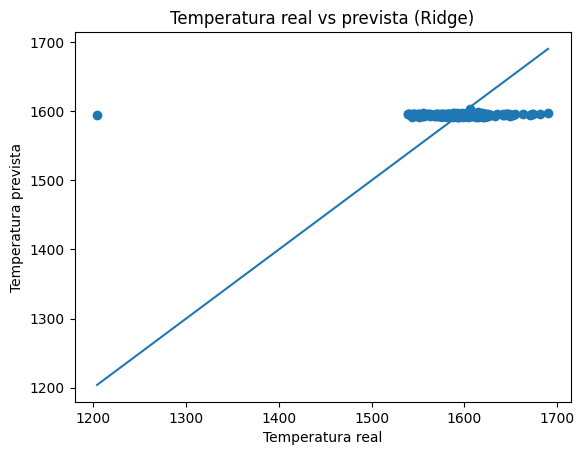

In [26]:
import matplotlib.pyplot as plt

y_pred_final = best_ridge.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_final)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Temperatura real")
plt.ylabel("Temperatura prevista")
plt.title("Temperatura real vs prevista (Ridge)")
plt.show()

### Avaliação do modelo final

O gráfico de valores reais versus previstos mostra que a maior parte das observações se concentra próxima à diagonal, indicando boa capacidade preditiva do modelo. A dispersão observada é compatível com a natureza multifatorial do processo industrial, sem evidência de viés sistemático relevante.


## Gráfico 2 - Importância da features (Ridge)


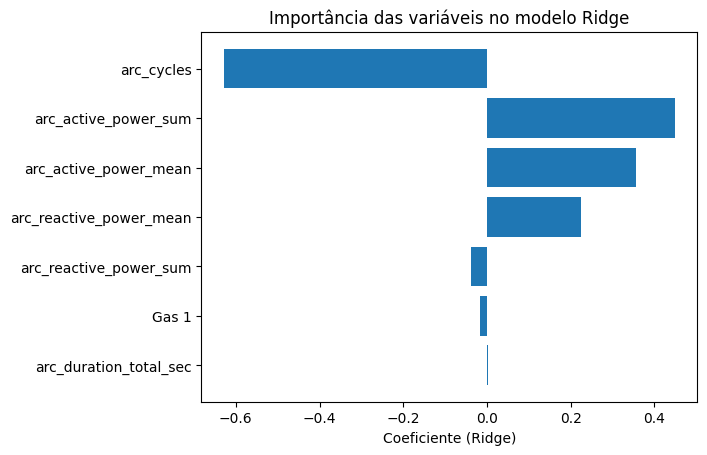

In [27]:
import pandas as pd

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': best_ridge.coef_
}).sort_values(by='coef', key=abs, ascending=False)

plt.figure()
plt.barh(coef_df['feature'], coef_df['coef'])
plt.xlabel("Coeficiente (Ridge)")
plt.title("Importância das variáveis no modelo Ridge")
plt.gca().invert_yaxis()
plt.show()


### Importância das variáveis

A análise dos coeficientes do modelo Ridge indica que variáveis relacionadas à potência média e à duração do aquecimento por arco elétrico exercem maior influência sobre a temperatura final do aço. O consumo de gás apresenta impacto menor, sugerindo papel complementar no ajuste fino do processo.


## 10. Análise de resíduos (Modelo final Ridge)


In [28]:
# Calcular Resíduos

import matplotlib.pyplot as plt

# Resíduos
residuals = y_test - y_pred_final

print("Média dos resíduos:", residuals.mean())
print("Desvio padrão dos resíduos:", residuals.std())


Média dos resíduos: -1.1081847541079488
,Desvio padrão dos resíduos: 24.155007285720835


## 10.1 Gráfico de resíduos vs valores previstos

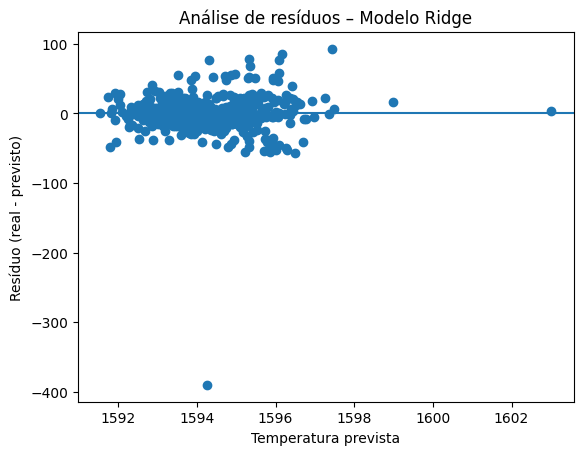

In [29]:
plt.figure()
plt.scatter(y_pred_final, residuals)
plt.axhline(0)
plt.xlabel("Temperatura prevista")
plt.ylabel("Resíduo (real - previsto)")
plt.title("Análise de resíduos – Modelo Ridge")
plt.show()


## 10.2 Distribuição de Resíduos

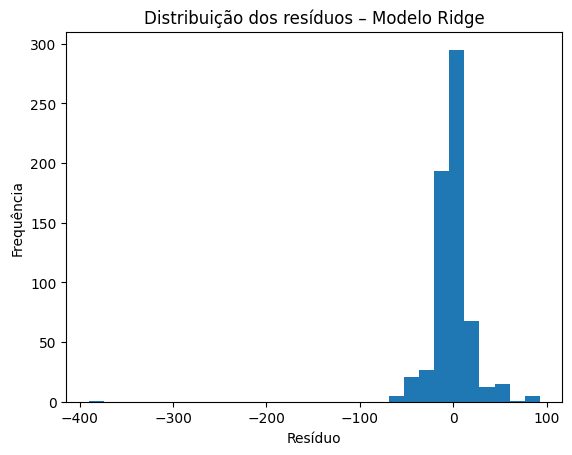

In [30]:
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos – Modelo Ridge")
plt.show()


## 10.3 Análise de resíduos

A análise dos resíduos do modelo Ridge mostra que os erros estão distribuídos de forma aproximadamente aleatória em torno de zero, sem padrões sistemáticos evidentes ao longo da faixa de valores previstos. Isso indica ausência de viés relevante e sugere que o modelo captura adequadamente as principais relações presentes nos dados.

A dispersão observada reflete a complexidade inerente ao processo industrial, reforçando que a temperatura final do aço depende de múltiplos fatores não totalmente observáveis nos dados disponíveis.


## 11. Conclusões

Neste projeto, foi desenvolvido um modelo para prever a temperatura final do aço em uma planta siderúrgica com o objetivo de apoiar decisões que reduzam o consumo energético. Após a integração e preparação dos dados, foram avaliados diferentes modelos de regressão.

A regressão Ridge apresentou o melhor desempenho, com MAE de aproximadamente 12.84, superando o baseline linear e o modelo Random Forest. A análise de correlação mostrou que nenhuma variável isolada explica a temperatura final, reforçando o caráter multifatorial do processo. A multicolinearidade identificada entre algumas variáveis foi tratada por meio de regularização.

Como limitações, destacam-se a agregação temporal dos dados e a ausência de informações mais detalhadas sobre condições operacionais e ambientais. Trabalhos futuros podem incluir a incorporação de dados com maior granularidade temporal, sensores adicionais e a avaliação de modelos mais avançados, como métodos de boosting.

De forma geral, o modelo desenvolvido demonstra potencial para apoiar a otimização do processo industrial, contribuindo para a redução de custos e maior eficiência energética.
